## Movies Dataset 2024 - Grupo 9
<hr style="border:1px solid gray">

# 1. Configuración inicial

## 1.1 Correr con UV

```shell
uv sync
uv run jupyter lab
```

## 1.2 Importar librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import kagglehub
from scipy import stats as st
from scipy.stats import describe
from pathlib import Path
import shutil

## 1.3 Importart dataset

In [4]:
# Create data directory if it doesn't exist
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Download dataset (latest version by default)
download_path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

# Copy to local data directory
csv_file = next(Path(download_path).glob("*.csv"))
local_path = data_dir / csv_file.name
shutil.copy2(csv_file, local_path)

print(f"Dataset copied to: {local_path}")

100%|██████████| 238M/238M [00:01<00:00, 136MB/s]


Extracting files...
Dataset copied to: data/TMDB_movie_dataset_v11.csv


## 1.4 Carga del dataset

In [5]:
# Cargamos el dataset desde el directorio local de datos
data_path = "data/TMDB_movie_dataset_v11.csv"
movies = pd.read_csv(data_path)

# 2. Descripción del dataset IMDB Movies 2024


| Variable              | Descripción                                                                                  |
|-----------------------|----------------------------------------------------------------------------------------------|
| `id`                  | Unique identifier for each movie. (type: int)                                                |
| `title`               | Title of the movie (usually in English or the display title). (type: str)                    |
| `vote_average`        | Average vote or rating given by viewers (typically 0–10 scale). (type: float)                |
| `vote_count`          | Total count of votes received for the movie. (type: int)                                     |
| `status`              | Current status of the movie (Released, Rumored, Post Production, etc.). (type: str)          |
| `release_date`        | Date when the movie was released (format usually YYYY-MM-DD). (type: str)                    |
| `revenue`             | Total revenue generated by the movie (in USD; 0 often means unknown/missing). (type: int)    |
| `runtime`             | Duration of the movie in minutes (0 usually means unknown). (type: int)                      |
| `adult`               | Indicates if the movie is only for adult audiences (true/false). (type: bool)                |
| `backdrop_path`       | Relative path to the backdrop image for the movie . (type: str)                              |
| `budget`              | Estimated production budget of the movie (USD; 0 often means unknown/missing). (type: int64) |
| `homepage`            | Official website URL of the movie (empty string or null if not available). (type: str)       |
| `imdb_id`             | IMDb identifier for the movie (format: tt followed by 7–8 digits). (type: str)               |
| `original_language`   | ISO 639-1 code of the original language of the movie (e.g., 'en', 'fr', 'es'). (type: str)   |
| `original_title`      | Original title of the movie (in its original language). (type: str)                          |
| `overview`            | Brief plot summary or synopsis of the movie. (type: str)                                     |
| `popularity`          | Popularity score assigned by TMDB (higher = more popular). (type: float64)                   |
| `poster_path`         | Relative path to the poster image for the movie (prepend https://image.tmdb.org) (type: str) |
| `tagline`             | Short marketing tagline or slogan of the movie (often empty). (type: str)                    |
| `genres`              | List of genres (usually as comma-separated string or JSON in some datasets). (type: str)     |
| `production_companies`| Name(s) of the main production company/companies (often comma-separated or JSON) (type: str) |
| `production_countries`| Country/countries where the movie was produced (often comma-separated or JSON). (type: str)  |
| `spoken_languages`    | Language(s) spoken in the movie (comma-separated or JSON. ISO codes and names). (type: str)  |
| `keywords`            | Descriptive keywords/tags linked with the movie (often comma-separated or JSON). (type: str) |

# 3. Primera inspección

## 3.1 Dimensiones del dataset original

In [6]:
print(f"Dimensiones del dataset original: {movies.shape}")
# exclude columns w/o valuable data (e.g. backdrop_path, imdb_id,..)
columns = ['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'popularity', 'genres', 'production_companies', 'production_countries', 'keywords']
movies[columns].head()

Dimensiones del dataset original: (1386763, 24)


,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,original_language,popularity,genres,production_companies,production_countries,keywords
0,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,160000000,en,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","rescue, mission, dream, airplane, paris, franc..."
1,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,165000000,en,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America","rescue, future, spacecraft, race against time,..."
2,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,185000000,en,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","joker, sadism, chaos, secret identity, crime f..."
3,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,237000000,en,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","future, society, culture clash, space travel, ..."
4,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,220000000,en,98.082,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"new york city, superhero, shield, based on com..."


In [7]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386763 entries, 0 to 1386762
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1386763 non-null  int64  
 1   title                 1386745 non-null  object 
 2   vote_average          1386763 non-null  float64
 3   vote_count            1386763 non-null  int64  
 4   status                1386763 non-null  object 
 5   release_date          1087689 non-null  object 
 6   revenue               1386763 non-null  int64  
 7   runtime               1386763 non-null  int64  
 8   adult                 1386763 non-null  bool   
 9   backdrop_path         347051 non-null   object 
 10  budget                1386763 non-null  int64  
 11  homepage              143036 non-null   object 
 12  imdb_id               661126 non-null   object 
 13  original_language     1386763 non-null  object 
 14  original_title        1386745 non-

In [8]:
movies[columns].describe()

,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.386763e+06,1.386763e+06,1.386763e+06,1.386763e+06,1.386763e+06,1.386763e+06
mean,1.586379e+00,1.547256e+01,6.250065e+05,4.434268e+01,2.393964e+05,1.034636e+00
std,2.875701e+00,2.884502e+02,1.922113e+07,6.077080e+01,5.100747e+06,6.883404e+00
min,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e-01
50%,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,2.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.300000e-01
max,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


## 3.2 Análisis de las variables numéricas

#### Nota: hay columnas con muchos valores en 0
IMDB usa el 0 para representar "unknown", no el valor 0. Por eso usamos alternativamente las siguientes medidas para obtener resultados útiles:
- `field_valid = movies['field'][movies['field'] > 0]` # subset de valores mayores a 0
- `movies['field'].replace(0, np.nan).mode()` # reemplazar 0 por NaN

In [9]:
movies['budget'].median() # example w/o filtering 0s

0.0

In [10]:
budget_valid = movies['budget'][movies['budget'] > 0]
budget_valid.median() # iltering 0s

3500.0

In [11]:
movies['popularity'].mean() # example w/o filtering 0s

np.float64(1.0346357596379894)

In [12]:
movies['popularity'].replace(0, np.nan).mean() # example filtering 0s

np.float64(1.2380071615747437)

#### Definir sets válidos

In [13]:
budget_valid = movies['budget'][movies['budget'] > 0]
revenue_valid = movies['revenue'][movies['revenue'] != 0] # movie can also lose money
popularity_valid = movies['popularity'][movies['popularity'] > 0]
vote_count_valid = movies['vote_count'][movies['vote_count'] > 0]
vote_average_valid = movies['vote_average'][movies['vote_average'] > 0]
runtime_valid = movies['runtime'][movies['runtime'] > 0]

#### Max/Mins

In [14]:
# Maximum budget
max_budget = budget_valid.max()
print(f"Maximum budget: ${max_budget:,}")

# Minimum budget
min_budget = budget_valid.min()
print(f"Minimum budget: ${min_budget:,}")

# Maximum revenue
max_revenue = revenue_valid.max()
print(f"Maximum revenue: ${max_revenue:,}")

# Minimum revenue
min_revenue = revenue_valid.min()
print(f"Minimum revenue: ${min_revenue:,}")

# Maximum popularity
max_popularity = popularity_valid.replace(0, np.nan).max()
print(f"Maximum popularity: {max_popularity:,}")

# Minimum popularity
min_popularity = popularity_valid.replace(0, np.nan).min()
print(f"Minimum popularity: {min_popularity:,}")

# Maximum vote_average
max_vote_average = vote_average_valid.replace(0, np.nan).max()
print(f"Maximum vote_average: {max_vote_average:,}")

# Minimum vote_average
min_vote_average = vote_average_valid.replace(0, np.nan).min()
print(f"Minimum vote_average: {min_vote_average:,}")

# Maximum vote_count
max_vote_count = vote_count_valid.replace(0, np.nan).max()
print(f"Maximum vote_count: {max_vote_count:,}")

# Minimum vote_count
min_vote_count = vote_count_valid.replace(0, np.nan).min()
print(f"Minimum vote_count: {min_vote_count:,}")

# Maximum runtime
max_runtime = runtime_valid.replace(0, np.nan).max()
print(f"Maximum runtime: {max_runtime:,}")

# Minimum vote_count
min_runtime = runtime_valid.replace(0, np.nan).min()
print(f"Minimum runtime: {min_runtime:,}")

Maximum budget: $999,999,999
Minimum budget: $1
Maximum revenue: $4,999,999,999
Minimum revenue: $-12
Maximum popularity: 2,994.357
Minimum popularity: 0.0071
Maximum vote_average: 10.0
Minimum vote_average: 0.5
Maximum vote_count: 34,495
Minimum vote_count: 1
Maximum runtime: 14,400
Minimum runtime: 1


## 3.3 Histogramas

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


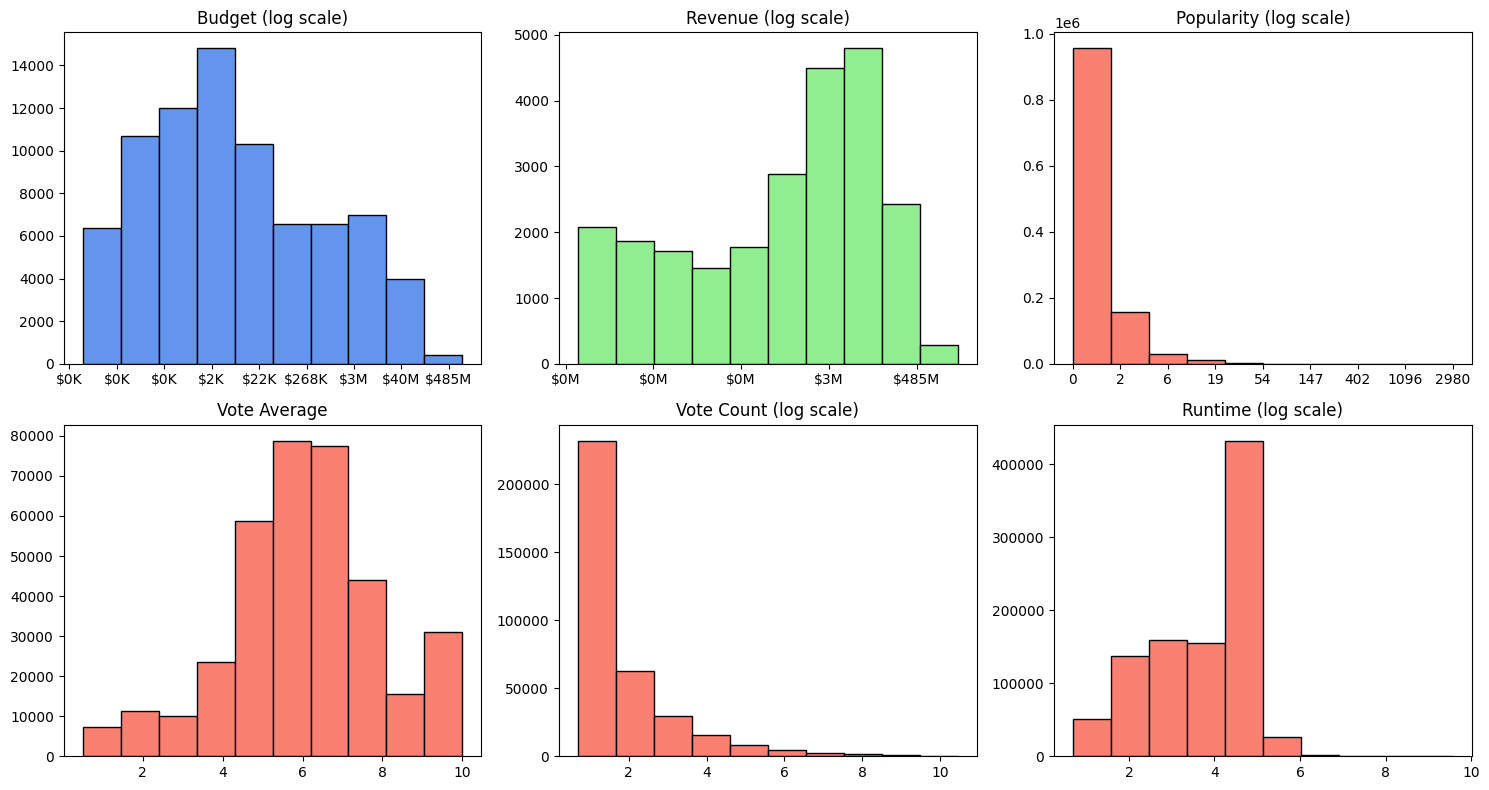

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# --- Budget ---
ax[0,0].hist(np.log1p(budget_valid), bins=10, color='cornflowerblue', edgecolor='black')
ax[0,0].set_title('Budget (log scale)')

# Nice original-scale tick labels
def log1p_inverse(y):
    return np.expm1(y)

ax[0,0].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"${log1p_inverse(y)/1e6:.0f}M" if y >= 13 else f"${log1p_inverse(y)/1e3:.0f}K"
))

# --- Revenue ---
# valid_revenue = movies['revenue'][movies['revenue'] > 0]  # also drop negative
ax[0,1].hist(np.log1p(revenue_valid), bins=10, color='lightgreen', edgecolor='black')
ax[0,1].set_title('Revenue (log scale)')
ax[0,1].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"${log1p_inverse(y)/1e6:.0f}M"
))

# --- Popularity ---
ax[0,2].hist(np.log1p(popularity_valid), bins=10, color='salmon', edgecolor='black')
ax[0,2].set_title('Popularity (log scale)')
ax[0,2].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"{log1p_inverse(y):.0f}"
))

# --- Vote Average ---
ax[1,0].hist(vote_average_valid, bins=10, color='salmon', edgecolor='black')
ax[1,0].set_title('Vote Average')

# --- Vote Count ---
ax[1,1].hist(np.log1p(vote_count_valid), bins=10, color='salmon', edgecolor='black')
ax[1,1].set_title('Vote Count (log scale)')

# --- Rubntime ---
ax[1,2].hist(np.log1p(runtime_valid), bins=10, color='salmon', edgecolor='black')
ax[1,2].set_title('Runtime (log scale)')

plt.tight_layout()
plt.show()

### Movies per month
<hr style="border:1px solid gray">


Standarize dates:

In [16]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

Visualize:

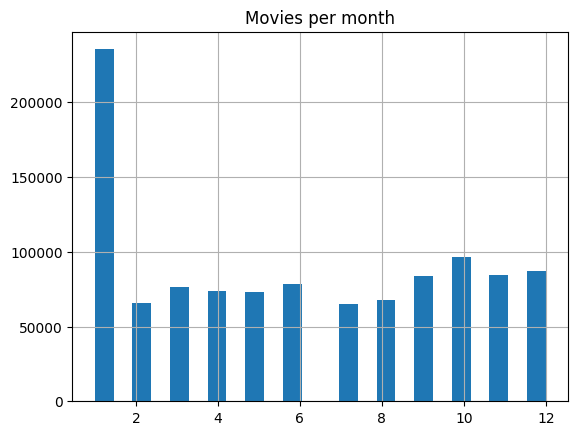

In [17]:
movies['release_month'] = movies['release_date'].dt.month
ax = movies['release_month'].hist(bins=24)
ax.set_title('Movies per month')
plt.show()

### 1. Medidas de tendencia central: media, mediana y moda
<hr style="border:1px solid gray">


#### Media

In [18]:
np.mean(budget_valid.replace(0, np.nan))    # Budget

np.float64(4220735.033691009)

In [19]:
np.mean(revenue_valid.replace(0, np.nan)) # Revenue

np.float64(36411354.11283818)

In [20]:
np.mean(popularity_valid) # Popularity

np.float64(1.2380071615747439)

In [21]:
np.mean(vote_count_valid.replace(0, np.nan)) # Vote count

np.float64(59.95589533805005)

In [22]:
np.mean(vote_average_valid.replace(0, np.nan)) # Vote average

np.float64(6.152002077763734)

In [23]:
np.mean(runtime_valid.replace(0, np.nan)) # Runtime

np.float64(63.89840318469418)

#### Mediana

In [24]:
np.median(budget_valid.replace(0, np.nan))  # Budget

np.float64(3500.0)

In [25]:
np.median(revenue_valid) # Revenue

np.float64(940000.0)

In [26]:
np.median(popularity_valid) # Popularity

np.float64(0.6)

In [27]:
np.median(vote_count_valid) # Vote count

np.float64(2.0)

In [28]:
np.median(vote_average_valid) # Vote average

np.float64(6.0)

In [29]:
np.median(runtime_valid) # Runtime

np.float64(62.0)

#### Moda

In [30]:
budget_valid.mode()[0]     # Budget

np.int64(100)

In [31]:
revenue_valid.mode()[0]     # Revenue

np.int64(1)

In [32]:
popularity_valid.mode()[0]     # Popularity

np.float64(0.6)

In [33]:
vote_count_valid.mode()[0]     # Vote count

np.int64(1)

In [34]:
vote_average_valid.mode()[0]     # Vote average

np.float64(6.0)

In [35]:
runtime_valid.mode()[0]     # Runtime

np.int64(90)

# 4. Análisis de inconsistencias

## 4.1 Películas duplicadas

In [36]:
# Dataset information
print(f"Amount of movies (rows): {len(movies)}")
print(f"Amount of unique movies: {movies['id'].nunique()}")
print(f"Amount of columns: {len(movies.columns)}")

# Check for duplicate IDs
duplicate_ids = movies['id'].duplicated().sum()
if duplicate_ids > 0:
    print(f"\n Found {duplicate_ids} duplicate movie IDs!")
else:
    print("\nAll movie IDs are unique")

Amount of movies (rows): 1386763
Amount of unique movies: 1385558
Amount of columns: 25

 Found 1205 duplicate movie IDs!


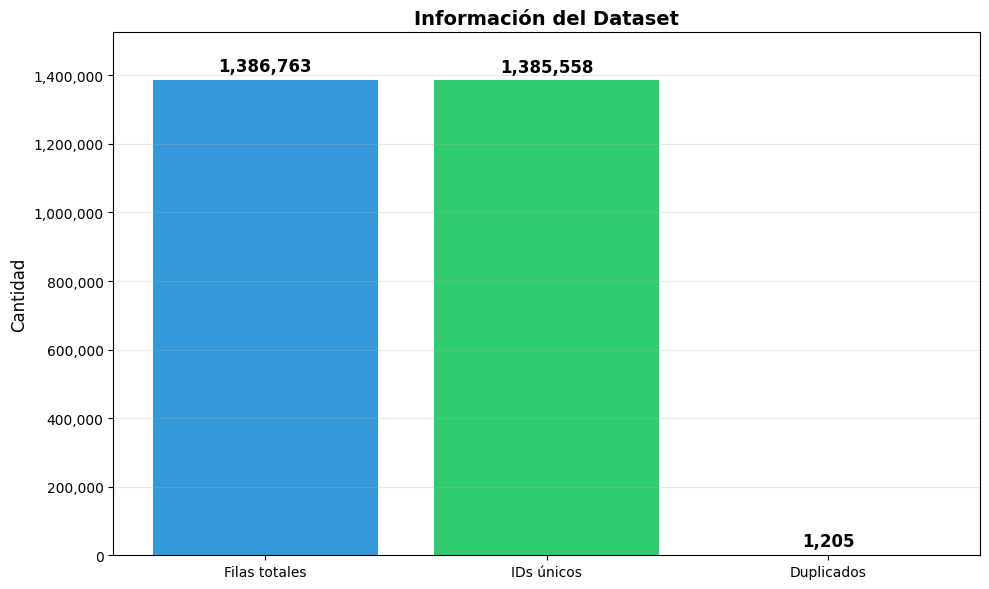

In [37]:
# Visualizar información del dataset
fig, ax = plt.subplots(figsize=(10, 6))

# Datos
categorias = ['Filas totales', 'IDs únicos', 'Duplicados']
valores = [len(movies), movies['id'].nunique(), len(movies) - movies['id'].nunique()]
colores = ['#3498db', '#2ecc71', '#e74c3c']

# Crear gráfico de barras
bars = ax.bar(categorias, valores, color=colores)

# Configurar etiquetas y título
ax.set_title('Información del Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad', fontsize=12)

# Formatear el eje Y para mostrar valores completos
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Ajustar escala del eje Y
max_val = max(valores)
ax.set_ylim(0, max_val * 1.1)

# Agregar valores sobre las barras
for bar, valor in zip(bars, valores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max_val * 0.01,
             f'{valor:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Agregar grid para mejor lectura
ax.grid(axis='y', alpha=0.3)

# Rotar etiquetas si es necesario
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 5. Análisis de variables categóricas



Analizamos algunas variables categóricas del dataset como idioma original, géneros y países de producción para entender su distribución dentro del dataset.



In [50]:
# Lista de columnas categóricas relevantes del dataset
categorical_columns = [
    "original_language",
    "genres",
    "production_countries",
    "production_companies",
    "keywords"
]

# Mostrar ejemplos de estas columnas
movies[categorical_columns].head()

,original_language,genres,production_countries,production_companies,keywords
0,en,"Action, Science Fiction, Adventure","United Kingdom, United States of America","Legendary Pictures, Syncopy, Warner Bros. Pict...","rescue, mission, dream, airplane, paris, franc..."
1,en,"Adventure, Drama, Science Fiction","United Kingdom, United States of America","Legendary Pictures, Syncopy, Lynda Obst Produc...","rescue, future, spacecraft, race against time,..."
2,en,"Drama, Action, Crime, Thriller","United Kingdom, United States of America","DC Comics, Legendary Pictures, Syncopy, Isobel...","joker, sadism, chaos, secret identity, crime f..."
3,en,"Action, Adventure, Fantasy, Science Fiction","United States of America, United Kingdom","Dune Entertainment, Lightstorm Entertainment, ...","future, society, culture clash, space travel, ..."
4,en,"Science Fiction, Action, Adventure",United States of America,Marvel Studios,"new york city, superhero, shield, based on com..."


### Idioma original de las películas

En primer lugar analizamos la variable `original_language`, que indica el idioma original de cada película.

Este análisis permite observar qué idiomas están más representados en el dataset y si existe una concentración importante en algunos idiomas particulares.

Para ello calculamos la cantidad de películas por idioma y visualizamos los más frecuentes mediante un gráfico de barras.

In [52]:
# Contar cuántas películas hay por idioma
language_counts = movies["original_language"].value_counts()

# Cantidad total de idiomas distintos
print("Cantidad de idiomas distintos:", movies["original_language"].nunique())

# Mostrar los 10 idiomas más frecuentes
language_counts.head(10)

Cantidad de idiomas distintos: 177


,count
original_language,
en,756895
fr,80717
es,70673
de,63083
ja,62334
zh,45168
pt,42945
it,28081
ru,27806


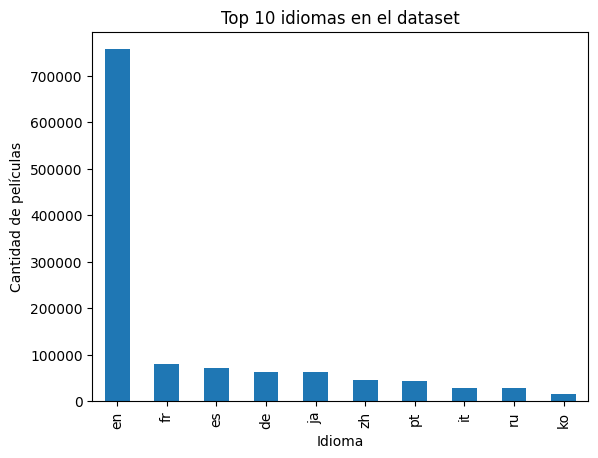

In [53]:
import matplotlib.pyplot as plt

# Gráfico de barras con los idiomas más frecuentes
language_counts.head(10).plot(kind="bar")

plt.title("Top 10 idiomas en el dataset")
plt.xlabel("Idioma")
plt.ylabel("Cantidad de películas")
plt.show()

### Géneros de las películas

La variable `genres` contiene los géneros asociados a cada película. En el dataset esta columna está almacenada como un string separado por comas (por ejemplo: `Action, Science Fiction, Adventure`).

Para poder analizar los géneros de forma individual, primero convertimos este string en una lista y luego utilizamos `explode()` para crear una fila por cada género asociado a una película.

De esta forma podemos calcular la frecuencia de cada género y analizar su popularidad promedio dentro del dataset.

In [67]:
movies["genres"].iloc[0]

['Action', 'Science Fiction', 'Adventure']

In [57]:
# La columna genres está almacenada como un string separado por comas
# Ejemplo: "Action, Science Fiction, Adventure"

# Primero convertimos ese string en una lista separando por coma

movies["genres"] = movies["genres"].fillna("").apply(lambda x: [g.strip() for g in x.split(",") if g])

# Ahora cada fila tiene una lista de géneros

movies["genres"].head()

,genres
0,"[Action, Science Fiction, Adventure]"
1,"[Adventure, Drama, Science Fiction]"
2,"[Drama, Action, Crime, Thriller]"
3,"[Action, Adventure, Fantasy, Science Fiction]"
4,"[Science Fiction, Action, Adventure]"


In [58]:
# "Aplanar" la lista de géneros
genres = movies.explode("genres")

# Verificar resultado
genres[["title","genres"]].head()

,title,genres
0,Inception,Action
0,Inception,Science Fiction
0,Inception,Adventure
1,Interstellar,Adventure
1,Interstellar,Drama


In [59]:
# Contar géneros
genre_counts = genres["genres"].value_counts()

genre_counts.head(10)

,count
genres,
Drama,256922
Documentary,193954
Comedy,156700
Animation,66133
Horror,63269
Romance,59315
Music,56021
Thriller,53978
Action,49354


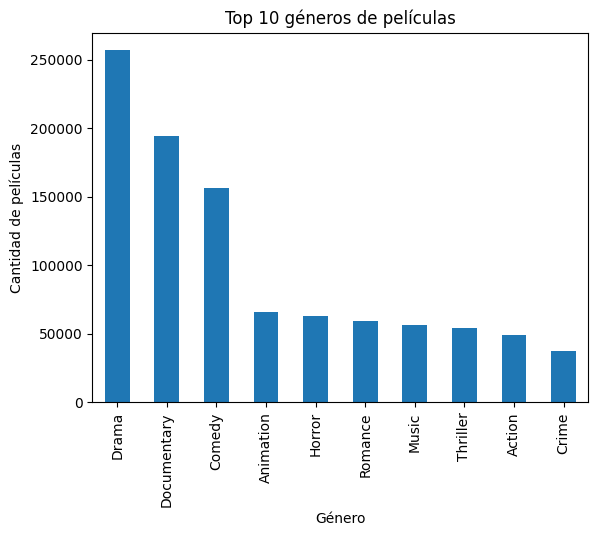

In [60]:
# Visualizar los géneros más frecuentes
genre_counts.head(10).plot(kind="bar")

plt.title("Top 10 géneros de películas")
plt.xlabel("Género")
plt.ylabel("Cantidad de películas")
plt.show()

In [61]:
# Calcular la popularidad promedio para cada género
genre_popularity = genres.groupby("genres")["popularity"].mean().sort_values(ascending=False)

genre_popularity.head(10)

,popularity
genres,
Adventure,4.276596
Action,3.823993
Thriller,3.340592
Science Fiction,3.255486
Fantasy,2.947101
Mystery,2.735243
Crime,2.724511
Family,2.706656
Romance,2.439316


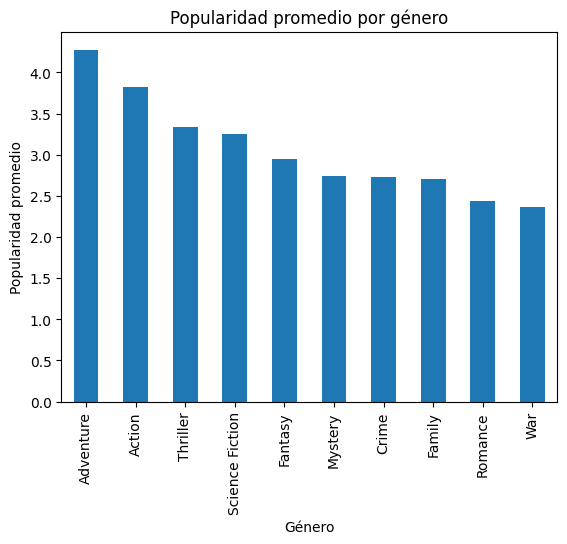

In [62]:
# Visualizar qué géneros tienen mayor popularidad promedio
genre_popularity.head(10).plot(kind="bar")

plt.title("Popularidad promedio por género")
plt.xlabel("Género")
plt.ylabel("Popularidad promedio")
plt.show()

### Países de producción

También analizamos los países de producción para identificar qué países participan con mayor frecuencia en la producción de películas del dataset.

In [68]:
# La columna production_countries también está almacenada como un string separado por comas
# Convertimos el string en una lista

movies["production_countries"] = movies["production_countries"].fillna("").apply(
    lambda x: [c.strip() for c in x.split(",") if c]
)

movies["production_countries"].head()

,production_countries
0,"[United Kingdom, United States of America]"
1,"[United Kingdom, United States of America]"
2,"[United Kingdom, United States of America]"
3,"[United States of America, United Kingdom]"
4,[United States of America]


In [69]:
# Aplanar la lista de países
countries = movies.explode("production_countries")

countries[["title","production_countries"]].head()

,title,production_countries
0,Inception,United Kingdom
0,Inception,United States of America
1,Interstellar,United Kingdom
1,Interstellar,United States of America
2,The Dark Knight,United Kingdom


In [70]:
# Conteo de países
country_counts = countries["production_countries"].value_counts()

country_counts.head(10)

,count
production_countries,
United States of America,214109
Japan,50411
France,50408
United Kingdom,47805
Germany,47560
Canada,26849
India,23409
Brazil,21208
Italy,20765


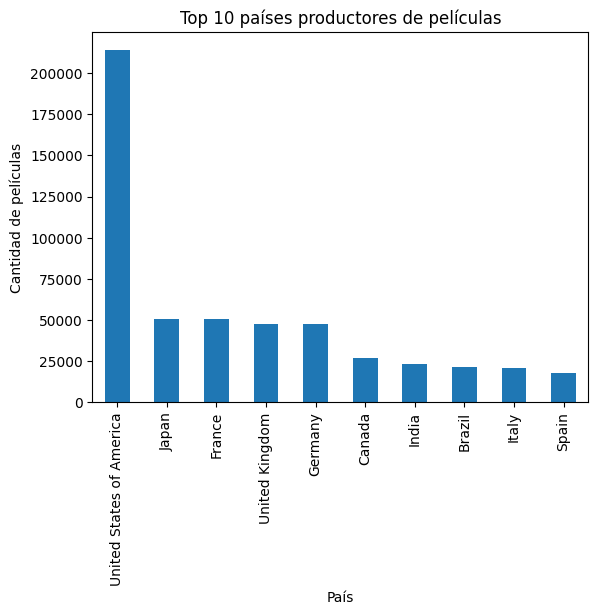

In [71]:
#Gráfico de países
country_counts.head(10).plot(kind="bar")

plt.title("Top 10 países productores de películas")
plt.xlabel("País")
plt.ylabel("Cantidad de películas")
plt.show()

### Productoras

Analizamos las productoras involucradas en las películas para identificar cuáles participan con mayor frecuencia en la producción cinematográfica.

In [75]:
movies["production_companies"].head()

,production_companies
0,"[Legendary Pictures, Syncopy, Warner Bros. Pic..."
1,"[Legendary Pictures, Syncopy, Lynda Obst Produ..."
2,"[DC Comics, Legendary Pictures, Syncopy, Isobe..."
3,"[Dune Entertainment, Lightstorm Entertainment,..."
4,[Marvel Studios]


In [76]:
# Aplanar la lista de productoras
companies = movies.explode("production_companies")

companies[["title", "production_companies"]].head()

,title,production_companies
0,Inception,Legendary Pictures
0,Inception,Syncopy
0,Inception,Warner Bros. Pictures
1,Interstellar,Legendary Pictures
1,Interstellar,Syncopy


In [77]:
#Conteo de productoras
company_counts = companies["production_companies"].value_counts()

company_counts.head(10)

,count
production_companies,
BBC,3419
Warner Bros. Pictures,3335
Evil Angel,3187
Columbia Pictures,2988
ARTE,2925
Metro-Goldwyn-Mayer,2900
ONF | NFB,2860
Universal Pictures,2794
Paramount,2658


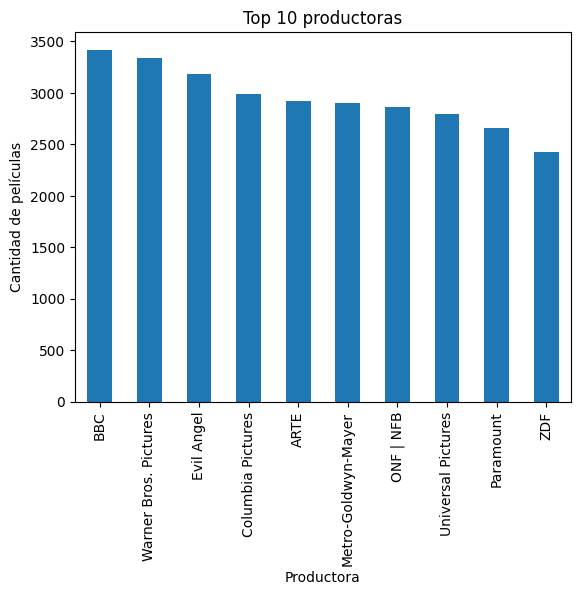

In [78]:
#Gráfico de productoras
company_counts.head(10).plot(kind="bar")

plt.title("Top 10 productoras")
plt.xlabel("Productora")
plt.ylabel("Cantidad de películas")
plt.show()

### Palabras clave (Keywords)

Las palabras clave permiten identificar los temas o conceptos más frecuentes en las películas del dataset.

In [100]:
movies["keywords"].head()

,keywords
0,"[rescue, mission, dream, airplane, paris, fran..."
1,"[rescue, future, spacecraft, race against time..."
2,"[joker, sadism, chaos, secret identity, crime ..."
3,"[future, society, culture clash, space travel,..."
4,"[new york city, superhero, shield, based on co..."


In [101]:
# Aplanar la lista de keywords
companies = movies.explode("keywords")

companies[["title", "keywords"]].head()

,title,keywords
0,Inception,rescue
0,Inception,mission
0,Inception,dream
0,Inception,airplane
0,Inception,paris


In [102]:
#Conteo de keywords
company_counts = companies["keywords"].value_counts()

company_counts.head(10)

,count
keywords,
short film,29358
woman director,16008
gay pornography,15535
based on novel or book,6557
anal sex,5944
concert,5225
lgbt,5222
compilation,4964
murder,4933


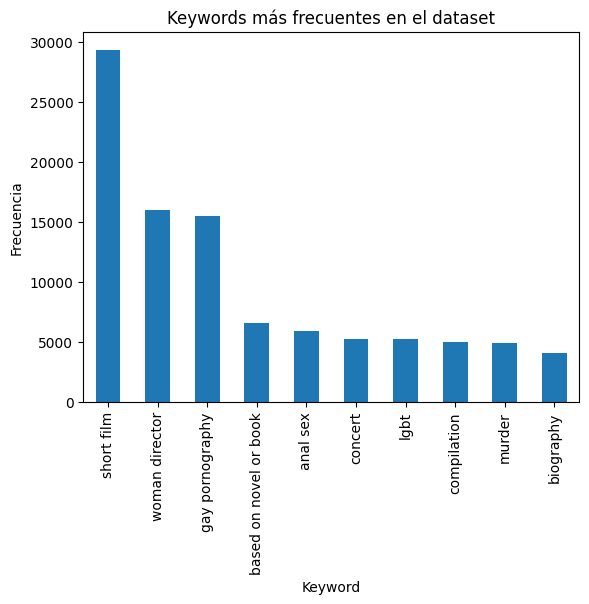

In [103]:
#Gráfico de keywords
keyword_counts.head(10).plot(kind="bar")

plt.title("Keywords más frecuentes en el dataset")
plt.xlabel("Keyword")
plt.ylabel("Frecuencia")
plt.show()

### Hallazgos

El análisis de variables categóricas muestra algunos patrones interesantes en el dataset:

- **Idioma original:** El inglés aparece como el idioma predominante en el dataset, lo cual es consistente con la fuerte presencia de producciones de la industria cinematográfica estadounidense. Otros idiomas aparecen con una frecuencia considerablemente menor.

- **Géneros:** Los géneros más frecuentes en el dataset son *Drama*, *Documentary* y *Comedy*. Esto indica que una gran parte del conjunto de películas analizadas pertenece a categorías narrativas o documentales, mientras que otros géneros aparecen con menor frecuencia.

- **Popularidad por género:** Al analizar la popularidad promedio por género se observa que *Adventure* y *Action* presentan los valores más altos de popularidad promedio. Esto sugiere que, aunque no sean los géneros más numerosos en el dataset, este tipo de películas tiende a generar mayor interés o visibilidad.

- **Países de producción:** La producción cinematográfica del dataset está fuertemente concentrada en algunos países. *United States of America* aparece como el principal país productor, seguido por *Japan*, *France* y *United Kingdom*. Esto refleja el peso de estas industrias cinematográficas dentro del conjunto de datos analizado.

- **Productoras:** Algunas compañías aparecen con mayor frecuencia dentro del dataset, lo que indica que ciertas productoras participan en múltiples proyectos y tienen un rol importante dentro del conjunto de películas analizado. Entre las productoras con mayor cantidad de películas se encuentran *BBC*, *Warner Bros. Pictures*, *Columbia Pictures* y *Universal Pictures*.

- **Palabras clave:** El análisis de keywords muestra que existen ciertos temas o características recurrentes en las películas del dataset. Entre las más frecuentes aparecen términos relacionados con formatos de producción (por ejemplo *short film*), características de dirección (*woman director*) o el origen de la obra (*based on novel or book*). Esto sugiere que el dataset incluye una amplia variedad de producciones y temáticas

En conjunto, el análisis de estas variables permite comprender mejor la estructura del dataset y las características principales de las películas incluidas. A su vez, el proceso de conversión de strings a listas y el uso de `explode()` permitió analizar correctamente estas variables categóricas.